In [1]:
from typing import Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from rich import print
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI

In [2]:
# Create a state class that includes a list of messages 
class State(TypedDict):
    message: Annotated[list, add_messages]

In [3]:
llm=ChatMistralAI(model_name="mistral-small-latest")

In [4]:
# Node Functionality 
def chatbot(state:State):
    return {"message":[llm.invoke(state['message'])]}

In [5]:
# Building Graph
graph_builder=StateGraph(State)
# Adding Nodes
graph_builder.add_node("llmchatbot",chatbot)
#Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
# Compiled Graph builder (Compile the graph builder)
graph=graph_builder.compile()

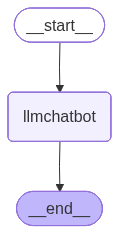

In [13]:
# Compile and Visualize the Graph (Or can use IPython Library)
graph_builder.compile()

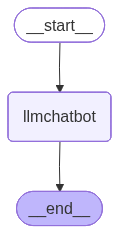

In [ ]:
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [ ]:
# Invoke the Compiled State Graph
response=graph.invoke({'message':"Tell me a joke"})

In [ ]:
print(response)

{
    'message': [
        HumanMessage(
            content='Tell me a joke',
            additional_kwargs={},
            response_metadata={},
            id='a25e0257-1bc1-4764-9530-fb97400d047f'
        ),
        AIMessage(
            content="Here's one for you:\n\n**Why don’t skeletons fight each other?**\n*Because they don’t have the
guts!* 😄\n\nWant another? Let me know!",
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 19,
                    'total_tokens': 58,
                    'completion_tokens': 39,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-latest',
                'model': 'mistral-small-latest',
                'finish_reason': 'stop',
                'model_provider': 'mistralai'
            },
            id='lc_run--019e00a8-829d-76c3-b689-2f71512e89c1-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 19, 'output_tokens': 39, 'total_tokens': 58}
        )
    ]
}

In [ ]:
print(response['message'][-1])

AIMessage(
    content="Here's one for you:\n\n**Why don’t skeletons fight each other?**\n*Because they don’t have the guts!* 
😄\n\nWant another? Let me know!",
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 19,
            'total_tokens': 58,
            'completion_tokens': 39,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-latest',
        'model': 'mistral-small-latest',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019e00a8-829d-76c3-b689-2f71512e89c1-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 19, 'output_tokens': 39, 'total_tokens': 58}
)

In [ ]:
print(response['message'][-1].content)

Here's one for you:

**Why don’t skeletons fight each other?**
*Because they don’t have the guts!* 😄

Want another? Let me know!

# Streaming 

Two types :

Stream --> Use to stream responses

astream--> More Deatiles info eassier for debuging

Each one have two modes:
1. updates : Provide the last AI message
2. value : Append all message one after other

In [7]:
for chunk in graph.stream({"message":"Explain ML to a 5 year old boy"},stream_mode="updates"):
    print(chunk)

{
    'llmchatbot': {
        'message': [
            AIMessage(
                content='Imagine you have a super-smart robot friend who learns from **toys** instead of 
books.\n\n1. **You show the robot a red ball.**\n   - It says, "This is a ball!"\n2. **You show a blue cube.**\n   
- It says, "This is a cube!"\n3. **Now, if you give the robot a new shape, it can guess:**\n   - "Is this a ball or
a cube?" → "It\'s a cube!" (because it remembers the colors and shapes you taught it).\n\nThat’s **Machine 
Learning**—the robot **learns from examples** like how you learn from your toys!\n\n🎯 **Simple Rule:** *The more 
things you show the robot, the smarter it gets!*',
                additional_kwargs={},
                response_metadata={
                    'token_usage': {
                        'prompt_tokens': 25,
                        'total_tokens': 182,
                        'completion_tokens': 157,
                        'prompt_tokens_details': {'cached_tokens': 0}
                    },
                    'model_name': 'mistral-small-latest',
                    'model': 'mistral-small-latest',
                    'finish_reason': 'stop',
                    'model_provider': 'mistralai'
                },
                id='lc_run--019e1bd5-d385-7193-8a9b-2eb6eb95a1a9-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={'input_tokens': 25, 'output_tokens': 157, 'total_tokens': 182}
            )
        ]
    }
}

In [8]:
for chunk in graph.stream({"message":"Explain ML to a 5 year old boy"},stream_mode="values"):
    print(chunk)

{
    'message': [
        HumanMessage(
            content='Explain ML to a 5 year old boy',
            additional_kwargs={},
            response_metadata={},
            id='9b355ed1-62eb-4c37-8e73-1f73d79ec113'
        )
    ]
}

{
    'message': [
        HumanMessage(
            content='Explain ML to a 5 year old boy',
            additional_kwargs={},
            response_metadata={},
            id='9b355ed1-62eb-4c37-8e73-1f73d79ec113'
        ),
        AIMessage(
            content='Oh, that’s a fun one! Let’s imagine you have a magic robot friend who’s really, really good at
guessing things. 🤖✨\n\nHere’s how it works:\n\n1. **Show and Learn**: You give the robot lots of pictures of cats
and dogs (like flashcards!). You say, *"This is a cat! This is a dog!"* over and over. The robot studies them and 
tries to find patterns—like cats have pointy ears and dogs have floppy ears.\n\n2. **Guessing Game**: Then, you 
show the robot a *new* picture it’s never seen before (like a blurry cat). The robot thinks, *"Hmm… pointy ears? 
Tail? Probably a cat!"* and guesses.\n\n3. **Mistakes Help!**: Sometimes it gets it wrong (like calling a raccoon a
cat), but you say, *"Nope! That’s a raccoon!"* and show it more examples. The robot learns from its mistakes, just 
like you do!\n\nSo, **Machine Learning (ML)** is like teaching a robot to make smart guesses by showing it lots of 
examples—just like how you learn your ABCs by seeing letters everywhere!\n\nWould you like to try teaching *your* 
stuffed animal to guess "yes" or "no" to questions? 😊',
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 25,
                    'total_tokens': 304,
                    'completion_tokens': 279,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-latest',
                'model': 'mistral-small-latest',
                'finish_reason': 'stop',
                'model_provider': 'mistralai'
            },
            id='lc_run--019e1bd6-5ddb-74d3-a6e1-c007d3205e15-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 25, 'output_tokens': 279, 'total_tokens': 304}
        )
    ]
}

In [12]:
# # For Debugging 
# async for event in graph.astream_events({"message":"Explain ML to a 5 year old boy"},stream_mode="updates"):
#     print(event)